0. Imports

In [207]:
import os
import re
import json
import polars
import spacy
import seaborn
import textstat
from matplotlib import pyplot


In [3]:
### reusable functions
def load_parquet(parquet_name: str):
    if os.path.exists(parquet_name):
        return polars.read_parquet(parquet_name)


1. CUAD Data loading

In [4]:
if (cuad_legal := load_parquet("0001_cuad_dataset.parquet")) is None:
    with open("./CUADv1.json") as cuad:
        cuad_json = json.load(cuad.buffer)

    legal_pieces = {}
    for data in cuad_json.get("data"):
        full_context = ""
        for paragraph in data.get("paragraphs"):
            if context := paragraph.get("context", ""):
                full_context += context
        legal_pieces[data.get("title")] = full_context


    cuad_legal = polars.DataFrame(legal_pieces)
    cuad_legal = cuad_legal.transpose(include_header=True)
    cuad_legal.columns = ["title", "paragraphs"]

    ### Parquet checkpoint
    cuad_legal.write_parquet("0001_cuad_dataset.parquet")


2. CUAD Data parsing

In [248]:
### Functions
def paragraphs_extractor(text):
    splitted = re.split(r"(\n\n|\t|\r)", text)
    return [re.sub(r"\s{2,}", " ", row) for row in splitted if "\n" not in row and row]

def extract_clauses(doc):
    CLAUSE_DEPS = {"ROOT", "ccomp", "xcomp", "advcl", "relcl", "conj"}
    def process_clauses(row):
        clauses = []
        nlp = doc(row)
        for token in nlp:
            if token.pos_ == "VERB" and token.dep_ in CLAUSE_DEPS:
                span = nlp[token.left_edge.i: token.right_edge.i + 1]
                clauses.append(span.text)
        return clauses
    return process_clauses

# Here we are trying to load cached file if it exists, otherwise we will need to reprocess everything
FILENAME = "cuad_sentence_extracted.parquet"

doc = spacy.load("en_core_web_sm")

if os.path.exists(FILENAME):
    cuad_legal = polars.read_parquet(FILENAME)
else:
    ### Logic application to dataset
    cuad_legal.select("title", "sentences").explode("sentences").with_columns(
        polars.col("sentences").map_elements(
            extract_clauses(doc),
            return_dtype=polars.List(polars.Utf8)
        ).alias("sentences")
    )

## Save checkpoint
cuad_legal.write_parquet("cuad_sentence_extracted.parquet")



3. Applying metrics
    - Flesch-Kincaid

In [249]:
### Grading the text complexity with Flesch-Kincaid
cuad_legal = cuad_legal.explode("sentences")
cuad_legal = cuad_legal.with_columns(polars.col("sentences").map_elements(lambda sentence: textstat.flesch_kincaid_grade(sentence)).alias("fk_grade"))


In [250]:

sample = cuad_legal.filter(polars.col("fk_grade") < 0).select("sentences").sample(10)
sample

sentences
str
"""3"""
"""Source: AZUL SA, F-1/A, 3/3/20…"
""" Page 22 of 32"""
"""6."""
"""5."""
"""38."""
"""Date: 4/26/16 Date: 4/26/2016"""
""" 6.3"""
""" 26"""


In [251]:
cuad_legal = cuad_legal.filter(polars.col("fk_grade") > 0)
cuad_legal

title,paragraphs,sentences,fk_grade
str,str,str,f64
"""LIMEENERGYCO_09_09_1999-EX-10-…","""EXHIBIT 10.6 …","""EXHIBIT 10.6""",8.79
"""LIMEENERGYCO_09_09_1999-EX-10-…","""EXHIBIT 10.6 …",""" DISTRIBUTOR AGREEMENT""",26.49
"""LIMEENERGYCO_09_09_1999-EX-10-…","""EXHIBIT 10.6 …",""" THIS DISTRIBUTOR AGREEMENT (t…",13.073333
"""LIMEENERGYCO_09_09_1999-EX-10-…","""EXHIBIT 10.6 …",""" RECITALS""",20.2
"""LIMEENERGYCO_09_09_1999-EX-10-…","""EXHIBIT 10.6 …",""" A. The Company's Business. Th…",14.42
…,…,…,…
"""PerformanceSportsBrandsInc_201…","""ENDORSEMENT AGREEMENT enter…",""" IN WITNESS WHEREOF, the parti…",10.5
"""PerformanceSportsBrandsInc_201…","""ENDORSEMENT AGREEMENT enter…",""" ANDY NORTH:""",2.89
"""PerformanceSportsBrandsInc_201…","""ENDORSEMENT AGREEMENT enter…","""GOLFERS INCORPORATED: /s/ Mich…",8.831765


4. Data Visualisation

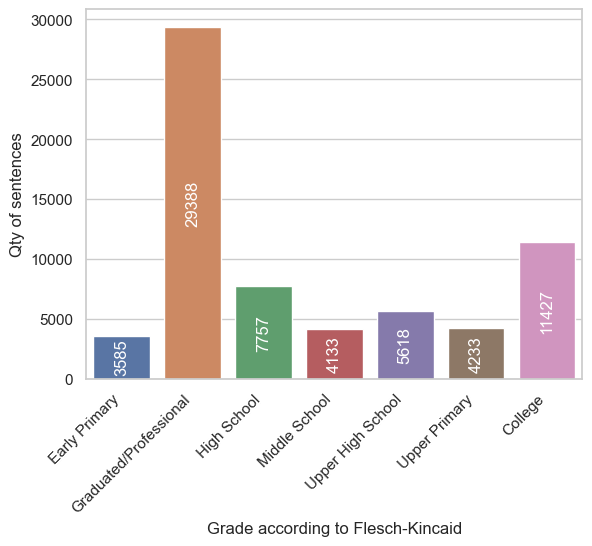

In [252]:
# Prepare and assign items based on Flesch-Kincaid metrics
# cuad_legal.filter(polars.col("fk_grade") > cuad_legal.select("fk_grade").mean()[0,0])
agg_by_grade = cuad_legal.with_columns(
    polars.when(polars.col("fk_grade") <= 3).then(polars.lit("Early Primary"))
    .when(polars.col("fk_grade") <= 6).then(polars.lit("Upper Primary"))
    .when(polars.col("fk_grade") <= 8).then(polars.lit("Middle School"))
    .when(polars.col("fk_grade") <= 10).then(polars.lit("High School"))
    .when(polars.col("fk_grade") <= 12).then(polars.lit("Upper High School"))
    .when(polars.col("fk_grade") <= 15).then(polars.lit("College"))
    .otherwise(polars.lit("Graduated/Professional"))
    .alias("grade_group")
)

pyplot.xticks(rotation=45, ha="right")
pyplot.xlabel("Grade according to Flesch-Kincaid")
pyplot.ylabel("Qty of sentences")
seaborn.set_theme(style="whitegrid")



ax = seaborn.barplot(
    agg_by_grade.group_by("grade_group").agg(polars.col("fk_grade").count()),
    x="grade_group",
    y="fk_grade",
    hue="grade_group"
)


for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height/2, f'{height:.0f}', 
            ha='center', va='center', color='white',rotation=90)



In [264]:
x = agg_by_grade.filter(polars.col("grade_group") == "Early Primary").sample(10)

In [265]:
x

title,paragraphs,sentences,fk_grade,grade_group
str,str,str,f64,str
"""DRAGONSYSTEMSINC_01_08_1999-EX…","""1 …",""" -3- 4 13. GOVERNING LAW""",2.88,"""Early Primary"""
"""UpjohnInc_20200121_10-12G_EX-2…","""Exhibit 2.6 FINAL VERSION FO…","""Source: UPJOHN INC, 10-12G, 1/…",0.52,"""Early Primary"""
"""UpjohnInc_20200121_10-12G_EX-2…","""Exhibit 2.6 FINAL VERSION FO…","""Source: UPJOHN INC, 10-12G, 1/…",0.52,"""Early Primary"""
"""UpjohnInc_20200121_10-12G_EX-2…","""Exhibit 2.6 FINAL VERSION FO…","""Source: UPJOHN INC, 10-12G, 1/…",0.52,"""Early Primary"""
"""HEALTHGATEDATACORP_11_24_1999-…","""EXHIBIT 10.1 …","""Set Journal Price""",1.313333,"""Early Primary"""
"""SLOVAKWIRELESSFINANCECOBV_03_2…","""Exhibit 4(b)(ii).3 …","""M&S contract -----------------…",2.89,"""Early Primary"""
"""ENERGYXXILTD_05_08_2015-EX-10.…","""Exhibit 10.13 TRANSPORTATION…","""Excess Water, Sediment, and Ot…",2.655866,"""Early Primary"""
"""SigaTechnologiesInc_20190603_8…","""Exhibit 10.1 Certain portions …","""by and between""",1.313333,"""Early Primary"""
"""InvendaCorp_20000828_S-1A_EX-1…","""1 *****Confidential Treatment …","""Source: INVENDA CORP, S-1/A, 8…",2.88,"""Early Primary"""


In [269]:
x.select("sentences")[6,0]

'Excess Water, Sediment, and Other Impurities Handling Block 22, Grand Isle 16 38.58 29.76 Block 30, Grand Isle 33 57.91 29.76 Block 73, West Delta 73 122.78 29.76 Block 90, West Delta 90 122.78 29.76 Block 62, West Delta 62 152.28 60.88 Block 54, South Timbalier 54 166.65 60.88 Block 30, West Delta 30 172.71 60.88 Block 32, West Delta 30 172.71 60.88 Block 45, West Delta 45 172.68 60.88 Block 93, South Pass 89 177.11 60.88 Block 152, Mississippi Canyon 268 242.01 &bbsp; 60.88 Block 311, Mississippi Canyon 311 242.01 60.88 Block 397, Mississippi Canyon 397 282.87 60.88 Block 280, Mississippi Canyon 281 291.11 60.88 Disposal Fee: _______________________'